In [1]:
from CSIreader import CSIscaler
import numpy as np

/usr/local/lib/python3.10/dist-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [2]:
csi_scaler = CSIscaler()

In [3]:
csi1 = '../../npsave/Tanaka/1112D00csic.npy'

In [4]:
csilist1, _, __, datetimelist1 = csi_scaler.load_npy_torch(path=csi1, remove_sm=True)

loaded
scaled
removed sm


In [5]:
print(csilist1[0][0])

tensor([[-16.0576-7.8970j,  29.4981-20.6367j,   0.7817+2.9016j],
        [ -0.5282-21.0716j,  56.7771-26.3682j,  -8.8535+11.4528j],
        [ -7.9843+10.6122j, -20.3865-8.1872j,   0.7732-6.2421j]],
       device='cuda:0')


In [6]:
dynamic_csi1 = csi_scaler.preprocess(csilist1)
print(dynamic_csi1.shape)

(304177, 30, 3, 3)


In [7]:
print(dynamic_csi1[0][0])

[[ 9.7130509e-03-6.0603310e-05j -3.1132235e-08+3.4078763e-08j
   1.9827292e-03-1.2776498e-03j]
 [-1.8027051e-03-2.6575662e-03j  8.0723481e-09-9.6654178e-09j
  -2.4190573e-04+4.1879569e-03j]
 [-1.1720352e-02-1.6456153e-02j  1.0453074e-08+2.4256579e-08j
  -1.0685919e-02+2.1000594e-02j]]


In [8]:
csi2 = '../../npsave/Tanaka/1112D02csic.npy'

In [9]:
csilist2, _, __, datetimelist2 = csi_scaler.load_npy_torch(path=csi2, remove_sm=True)

loaded
scaled
removed sm


In [10]:
dynamic_csi2 = csi_scaler.preprocess(csilist2)
print(dynamic_csi2.shape)

(138206, 30, 3, 3)


In [11]:
print(dynamic_csi2[0][0])

[[-7.5131659e-03-5.24641387e-03j -2.6801020e-08-1.45121914e-08j
  -6.3948417e-03+1.05458777e-02j]
 [-1.2747663e-03+8.08388181e-03j  8.6698915e-09-1.22491368e-08j
  -1.2457688e-02-2.04900396e-03j]
 [-1.9168468e-02+1.01530449e-02j  1.9336861e-08+2.09465814e-08j
   6.6251880e-03+1.55999698e-02j]]


In [13]:
csi_concat = np.concat((dynamic_csi1, dynamic_csi2), 0)
print(csi_concat.shape)

(442383, 30, 3, 3)


In [14]:
np.save('../../dataset/Tanaka_Toy/csi.npy', csi_concat)

In [15]:
datetimelist_concat = np.concat((datetimelist1, datetimelist2), 0)
print(datetimelist_concat.shape)

In [18]:
np.save('../../dataset/Tanaka_Toy/csitime.npy', datetimelist_concat)

In [20]:
camtime1 = np.load('../../dataset/Tanaka_Raw/20251112_144210-camtime.npy')

In [21]:
camtime2 = np.load('../../dataset/Tanaka_Raw/20251112_151030-camtime.npy')

In [24]:
camtime_concat = np.concat((camtime1[:5000], camtime2[:3000]), 0)

In [25]:
print(camtime_concat.shape)

(8000,)


In [26]:
np.save('../../dataset/Tanaka_Toy/camtime.npy', camtime_concat)

In [27]:
print(camtime_concat[:2], datetimelist_concat[:2])

[1.76292613e+09 1.76292613e+09] [1.76292613e+09 1.76292613e+09]


In [28]:
csi_inds = np.searchsorted(datetimelist_concat, camtime_concat)

In [29]:
print(csi_inds[:10])

[3564 3598 3631 3665 3698 3731 3765 3798 3831 3865]


In [30]:
np.save('../../dataset/Tanaka_Toy/matched_inds.npy', csi_inds)

In [16]:
print(csi_concat.dtype)

complex64


In [2]:
csi = np.load('../../dataset/Door_Days/A208D1/0111D01-csi.npy')

In [3]:
print(csi.shape)

(698388, 30, 3)


In [4]:
print(csi.dtype)

complex128


In [5]:
csi = np.load('../../dataset/Tanaka_Toy/csi.npy')
print(csi.shape, csi.dtype)

(442383, 30, 3, 3) complex64


In [ ]:
import numpy as np
time = np.load()

In [1]:
from CSIreader_cpu import CSIscaler

In [2]:
csi_scaler = CSIscaler()

In [3]:
csi1 = '../../npsave/Tanaka/1112D00csic.npy'

In [4]:
csilist1, _, __, datetimelist1 = csi_scaler.load_npy(path=csi1, remove_sm=True)

loaded
scaled
removed sm


In [5]:
dynamic_csi1 = csi_scaler.preprocess(csilist1)

In [7]:
print(dynamic_csi1.shape)

(304177, 30, 3, 3)


In [9]:
csi_scaler.save(path='../../dataset/csi.npy')

Saved CSI and csitime!


In [1]:
from Imageloader import ImageLoader

In [2]:
imgloader = ImageLoader('../../dataset/Tanaka_Raw/20251217_163642-depthimg.npy')
imgloader.browse_images()

 Loaded 20251217_163642-depthimg.npy of (9128, 128, 226) as uint16


interactive(children=(IntSlider(value=4563, description='i', max=9127), Output()), _dom_classes=('widget-inter…

Data reset!
Masking...Done


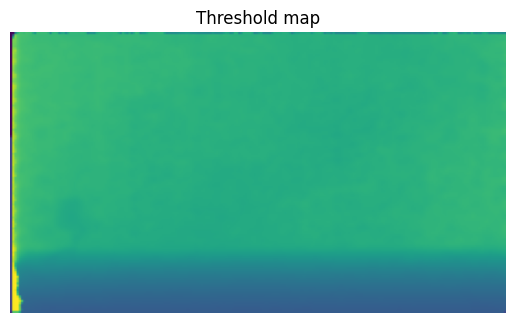

Binarization done


interactive(children=(IntSlider(value=4563, description='i', max=9127), Output()), _dom_classes=('widget-inter…

In [3]:
imgloader.reset_data()
imgloader.depth_mask(0.8)
imgloader.binarize()
imgloader.browse_images()

In [4]:
imgloader.save_images('../../dataset/Tanaka_Processed')

Saving 20251217_163642-depthimg.npy...Done
